<font size="+3">Protenix-v2 benchmark on TCR:epitope interactions</font> <br>

In [2]:
import glob
import os
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.decomposition import PCA

from Bio.PDB import PDBParser, NeighborSearch, PDBIO, Superimposer, MMCIFParser
from Bio.SeqUtils import seq1



# IMMREP23

In [ ]:
df = pd.read_csv('IMMREP23_unseen.csv')
df = df.rename(columns={'model':'epitope', 'epitope':'peptide', 'MHC':'MHC_allele_a'})
df = df.drop(columns=['MHC_class'])
df['MHC_allele_a'] = 'HLA_' + df['MHC_allele_a']
df = df[df['peptide'].isin(['SALPTNADLY', 'TDLGQNLLY', 'VSDGGPNLY'])]
df = df.sort_values(by='peptide')
df['id'] = [f'tcr_{i:04}' for i in range(len(df))]
# move 'id' to the first column position
df.insert(0, 'id', df.pop('id'))

genes = ['TRAV', 'TRAJ', 'TRBV', 'TRBJ']
for g in genes:
    df[g] = df[g].str.split('*').str[0]

df.to_csv('IMMREP23_unseen_clean.csv')

In [3]:
df_input = pd.read_csv('IMMREP23_unseen_clean.csv')
df_input = df_input.drop(columns = ['Unnamed: 0'])
df_input = df_input.rename(columns={'Label':'label'})

df_output = pd.read_csv(f'IMMREP23/output.csv')
df_output.columns = df_output.columns.str.lower()

df = pd.merge(df_input, df_output, on='id')

df['epitope'] = df['MHC_allele_a'].str[4:] + '_' + df['peptide']
df.to_csv(f'IMMREP23/output_anno.csv')

     Unnamed: 0        id           epitope         cdr3_TRA  \
0             0  tcr_0000  A0101_SALPTNADLY     CAVGDNFNKFYF   
1             1  tcr_0001  A0101_SALPTNADLY     CAVRGSNYQLIW   
2             2  tcr_0002  A0101_SALPTNADLY  CAYRSAVGSQGNLIF   
3             3  tcr_0003  A0101_SALPTNADLY    CVARGGATNKLIF   
4             4  tcr_0004  A0101_SALPTNADLY      CAVSPGTRLMF   
..          ...       ...               ...              ...   
647         647  tcr_0647   A0101_VSDGGPNLY   CAASTGGSQGNLIF   
648         648  tcr_0648   A0101_VSDGGPNLY    CVARGGATNKLIF   
649         649  tcr_0649   A0101_VSDGGPNLY    CAPNKAAGNKLTF   
650         650  tcr_0650   A0101_VSDGGPNLY  CALSETGRDTDKLIF   
651         651  tcr_0651   A0101_VSDGGPNLY   CVVNKGAGGFKTIF   

             cdr3_TRB          TRAV    TRAJ      TRBV     TRBJ      species  \
0      CASAPTSAMGEQYF       TRAV8-3  TRAJ21    TRBV28  TRBJ2-7  HomoSapiens   
1        CASSPHSYEQYF        TRAV21  TRAJ33   TRBV5-4  TRBJ2-7  HomoSapie

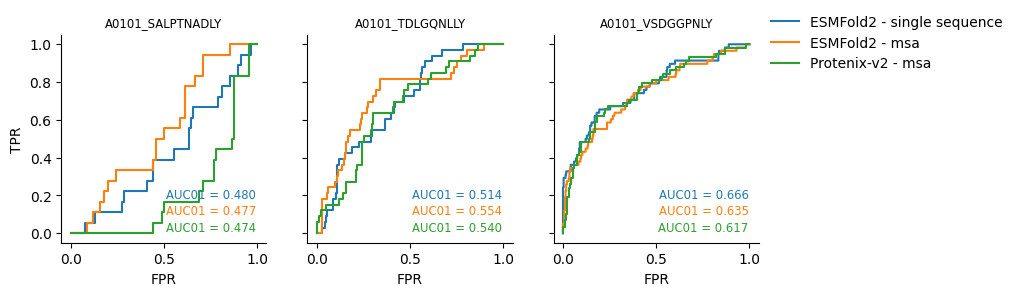

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(9, 2.7), sharex=True, sharey=True)

topdirs = {'ESMFold2 - single sequence' : '../260617_test_ESMFold2/IMMREP23/single-sequence', 
           'ESMFold2 - msa' :'../260617_test_ESMFold2/IMMREP23/msa', 
           'Protenix-v2 - msa' :'IMMREP23'}

colors = {
    'ESMFold2 - single sequence': 'C0',
    'ESMFold2 - msa': 'C1',
    'Protenix-v2 - msa': 'C2',
}

legend_handles = []

for i, (label, topdir) in enumerate(topdirs.items()):
    df = pd.read_csv(f'{topdir}/output_anno.csv')
    print(df)
    color = colors[label]

    topdir_records = []

    for cnt, (name, group) in enumerate(df.groupby('epitope')):
        ax = axes[cnt]

        y_true = group['label'].values
        y_scores = group['iptm_pair_mean'].values

        fpr, tpr, _ = roc_curve(y_true, y_scores)
        auc = roc_auc_score(y_true, y_scores)
        auc01 = roc_auc_score(y_true, y_scores, max_fpr=0.1)

        line, = ax.plot(fpr, tpr, color=color)

        ax.set_title(name, fontsize='small')

        # stack AUC01 labels for up to 3 topdirs without overlapping
        y_pos = 0.2 - 0.08 * i
        ax.text(0.95, y_pos, f"AUC01 = {auc01:.3f}", transform=ax.transAxes,
                ha='right', va='bottom', fontsize='small', color=color)

        ax.set_xlabel('FPR')
        if cnt == 0:
            ax.set_ylabel('TPR')

        topdir_records.append({'epitope': name, 'auc': auc, 'auc01': auc01})

        if cnt == 0:
            legend_handles.append(line)

    df_auc = pd.DataFrame(topdir_records)
    #df_auc.to_csv(f'IMMREP23/{topdir}/output_auc.csv', index=False)
    print(topdir)
    print(df_auc.head())

sns.despine()
fig.legend(legend_handles, topdirs, loc='upper left',
           bbox_to_anchor=(0.9, 1.0), frameon=False)